Предмет "Искусственный интеллект"

Лабораторная работа №8

Грибушенков Михаил, группа РФЗ-2-2022

Определение эмоционального окраса сообщения по содержанию

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# defines
filename = "Tweets.csv"

In [49]:
db = pd.read_csv (filename, sep=",") # Загрузка базы данных из файла
db = db.drop("textID", axis = 1)
db.info() # Статистика по БД
db.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           27480 non-null  object
 1   selected_text  27480 non-null  object
 2   sentiment      27481 non-null  object
dtypes: object(3)
memory usage: 644.2+ KB


,text,selected_text,sentiment
0,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,my boss is bullying me...,bullying me,negative
3,what interview! leave me alone,leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
5,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,neutral
6,2am feedings for the baby are fun when he is a...,fun,positive
7,Soooo high,Soooo high,neutral
8,Both of you,Both of you,neutral
9,Journey!? Wow... u just became cooler. hehe....,Wow... u just became cooler.,positive


In [4]:
!pip install sklearn
!pip install  keras
!pip install  nltk
!pip install  pandas
!pip install  numpy
!pip install  re
!pip install  codecs

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re
ERROR: Could not find a version that satisfies the requirement codecs (from versions: none)
ERROR: No matching distribution found for codecs


In [5]:
import sklearn
import keras
import nltk
import pandas as pd
import numpy as np
import re
import codecs

In [50]:
# Приведем все к младшему регистру, изничтожим url, уберем большинство знаков препинания
def standardize_text(df, text_field):
    df[text_field] = df[text_field].str.replace(r"http\S+", "")
    df[text_field] = df[text_field].str.replace(r"http", "")
    df[text_field] = df[text_field].str.replace(r"@\S+", "")
    df[text_field] = df[text_field].str.replace(r"[^A-Za-z0-9(),!?@\'\`\"\_\n]#", " ")
    df[text_field] = df[text_field].str.replace(r"@", "at")
    df[text_field] = df[text_field].str.lower()
    return df

db = standardize_text(db, "text")
db = standardize_text(db, "selected_text")
db.head()

,text,selected_text,sentiment
0,"i`d have responded, if i were going","i`d have responded, if i were going",neutral
1,sooo sad i will miss you here in san diego!!!,sooo sad,negative
2,my boss is bullying me...,bullying me,negative
3,what interview! leave me alone,leave me alone,negative
4,"sons of ****, why couldn`t they put them on t...","sons of ****,",negative


Работает.

In [51]:
db.groupby("sentiment").count()

,text,selected_text
sentiment,,
negative,7781,7781
neutral,11117,11117
positive,8582,8582


Почти сбалансированное.

In [52]:
db["sentiment"] = [{"neutral": 0, "negative": -1, "positive": 1}[cat] for cat in db["sentiment"]]
# Ибо код дальнейший ругается на нечисленный целевой признак

In [53]:
# Токенизация текстов сообщений в отдельные слова

from nltk.tokenize import RegexpTokenizer

db["text"] = db["text"].astype("str") # А без того ругается, что текст - float, вот так-то.
tokenizer = RegexpTokenizer(r'\w+|\$[\d\.]+|\S+')
db["tokens"] = db["text"].apply(tokenizer.tokenize)
db.head()

,text,selected_text,sentiment,tokens
0,"i`d have responded, if i were going","i`d have responded, if i were going",0,"[i, `d, have, responded, ,, if, i, were, going]"
1,sooo sad i will miss you here in san diego!!!,sooo sad,-1,"[sooo, sad, i, will, miss, you, here, in, san,..."
2,my boss is bullying me...,bullying me,-1,"[my, boss, is, bullying, me, ...]"
3,what interview! leave me alone,leave me alone,-1,"[what, interview, !, leave, me, alone]"
4,"sons of ****, why couldn`t they put them on t...","sons of ****,",-1,"[sons, of, ****,, why, couldn, `t, they, put, ..."


In [54]:
all_words = [word for tokens in db["tokens"] for word in tokens]
sentence_lengths = [len(tokens) for tokens in db["tokens"]]
VOCAB = sorted(list(set(all_words)))
print("Всего слов: %s\nРазмер словаря: %s\nМаксимальная длина предложения: %s" % (len(all_words), len(VOCAB), max(sentence_lengths)))

Всего слов: 408666
Размер словаря: 30818
Максимальная длина предложения: 44


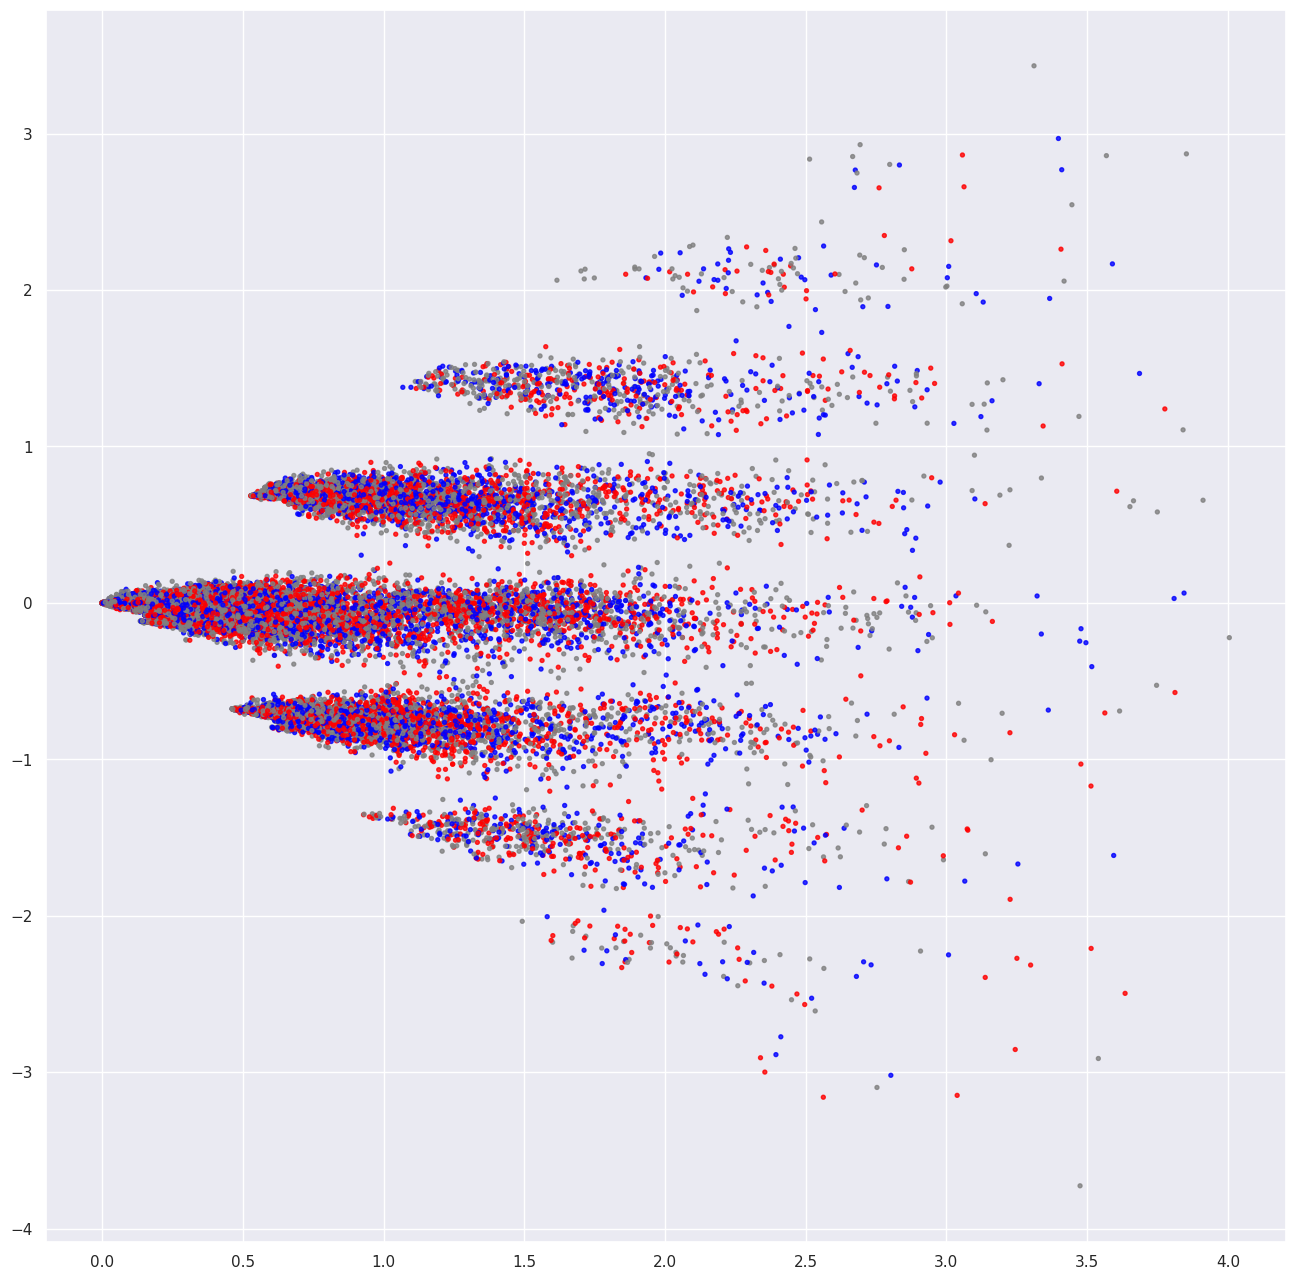

In [55]:
# Векторизация текста

from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

def cv(data):
    count_vectorizer = CountVectorizer()
    emb = count_vectorizer.fit_transform(data)
    return emb, count_vectorizer

list_corpus = db["text"].tolist()
list_labels = db["sentiment"].tolist()

X_train, X_test, y_train, y_test = train_test_split(list_corpus, list_labels, test_size=0.2,
                                                                                random_state=40)

X_train_counts, count_vectorizer = cv(X_train)
X_test_counts = count_vectorizer.transform(X_test)

# Визуализация сего

def plot_LSA(test_data, test_labels, savepath="PCA_demo.csv"):
        lsa = TruncatedSVD(n_components=2)
        lsa.fit(test_data)
        lsa_scores = lsa.transform(test_data)
        color_mapper = {label:idx for idx,label in enumerate(set(test_labels))}
        color_column = [color_mapper[label] for label in test_labels]
        colors = {0: "gray", -1: "blue", 1: "red"}  # Да.

        plt.scatter(lsa_scores[:,0], lsa_scores[:,1], s=8, alpha=.8, c = [colors[lilhamster] for lilhamster in test_labels])


fig = plt.figure(figsize=(16, 16))
plot_LSA(X_train_counts, y_train)
plt.show()

Красное - позитивный отзыв, серое - нейтиральный, синее - негативный.

In [56]:
# Логистическая регрессия для угадывания настроя сообщения

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(C=30.0, class_weight='balanced', solver='newton-cg',
                         multi_class='multinomial', n_jobs=-1, random_state=40)
clf.fit(X_train_counts, y_train)

y_predicted_counts = clf.predict(X_test_counts)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [57]:
print (y_test)
print (y_predicted_counts.tolist())

[-1, 0, -1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, -1, 0, 1, 1, 0, -1, -1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, -1, 1, 1, 1, 0, 1, 1, 0, 1, 0, -1, 0, 1, 1, 1, 0, 0, 1, 0, 1, -1, 0, 0, 0, -1, 0, 1, -1, 0, 0, 1, 1, -1, 1, 0, 0, -1, 1, 1, 0, -1, 1, 1, 1, 1, 0, 0, -1, -1, -1, 1, -1, -1, -1, -1, 0, 0, 1, -1, 0, 0, -1, -1, -1, 1, 1, 1, -1, 1, 1, 0, -1, 1, 0, -1, -1, -1, 1, 0, 0, 0, 1, 1, 0, 1, 1, -1, 0, 1, -1, -1, -1, 0, 0, 1, 1, 0, -1, 1, 0, 1, 1, -1, 0, 1, 0, -1, 1, 1, 1, -1, 1, 0, 0, -1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, -1, 1, 0, 1, -1, -1, 0, 1, -1, 1, 1, 0, 1, 0, 0, 1, -1, 1, 0, 1, 0, -1, 1, -1, 1, 0, 1, -1, -1, 0, 1, 0, 0, 0, 0, -1, 1, 1, 0, 1, 1, 1, 1, 1, -1, 0, 0, 1, -1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, -1, 0, 1, -1, 1, 0, 0, 1, -1, 1, -1, 0, -1, 1, 1, 0, 0, -1, 1, 1, 0, 1, 0, -1, -1, 0, 0, 0, 0, -1, 0, -1, 1, -1, -1, 0, -1, 0, -1, 0, 1, 1, 0, 1, 1, 1, -1, 0, 1, 1, 1, 1, 1, 0, -1, 1, -1, 1, 1, -1, -1, 1, -1, 1, 0, 0, 0, -1, 1, -1, 0, 1, -1, 0, -1, -1, -1, 0,

In [59]:
# И метрики логистической регрессии

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, r2_score, classification_report

def get_metrics(y_test, y_predicted):
    precision = precision_score(y_test, y_predicted, pos_label=None,
                                    average='weighted')
    recall = recall_score(y_test, y_predicted, pos_label=None,
                              average='weighted')

    f1 = f1_score(y_test, y_predicted, pos_label=None, average='weighted')

    r2 = r2_score(y_test, y_predicted)
    accuracy = accuracy_score(y_test, y_predicted)
    return accuracy, precision, recall, f1, r2

accuracy, precision, recall, f1, r2 = get_metrics(y_test, y_predicted_counts)
print("accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f, r2 = %.3f" % (accuracy, precision, recall, f1,r2))

accuracy = 0.653, precision = 0.653, recall = 0.653, f1 = 0.653, r2 = 0.213


Точность выше 0,5, что радует.

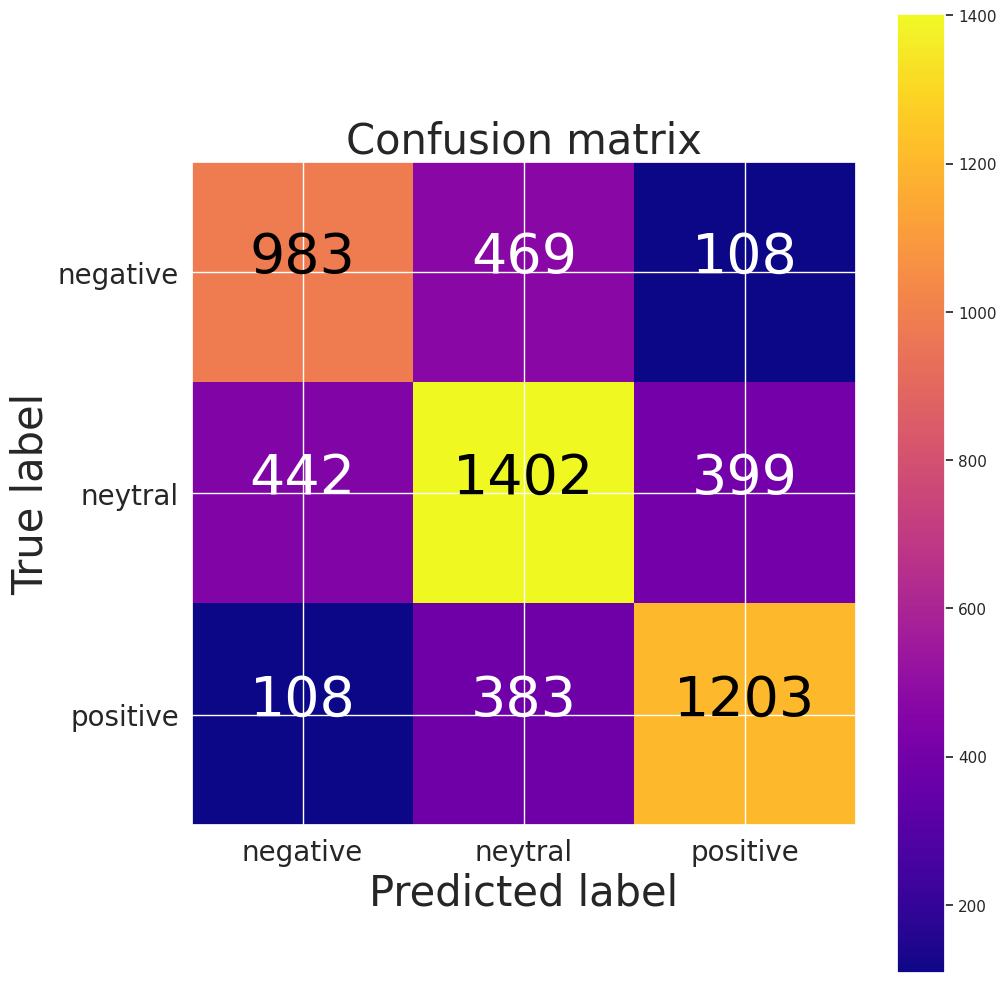

In [60]:
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.winter):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=30)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=20)
    plt.yticks(tick_marks, classes, fontsize=20)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] < thresh else "black", fontsize=40)

    plt.tight_layout()
    plt.ylabel('True label', fontsize=30)
    plt.xlabel('Predicted label', fontsize=30)

    return plt

cm = confusion_matrix(y_test, y_predicted_counts)
fig = plt.figure(figsize=(10, 10))
plot = plot_confusion_matrix(cm, classes=["negative", "neytral", "positive"], normalize=False, title='Confusion matrix', cmap="plasma")
plt.show()

КЛассификатор чаще всего путает действительно негативные и позитивные тексты с нейтральными, между собой же негативные и позитивные путает реже.

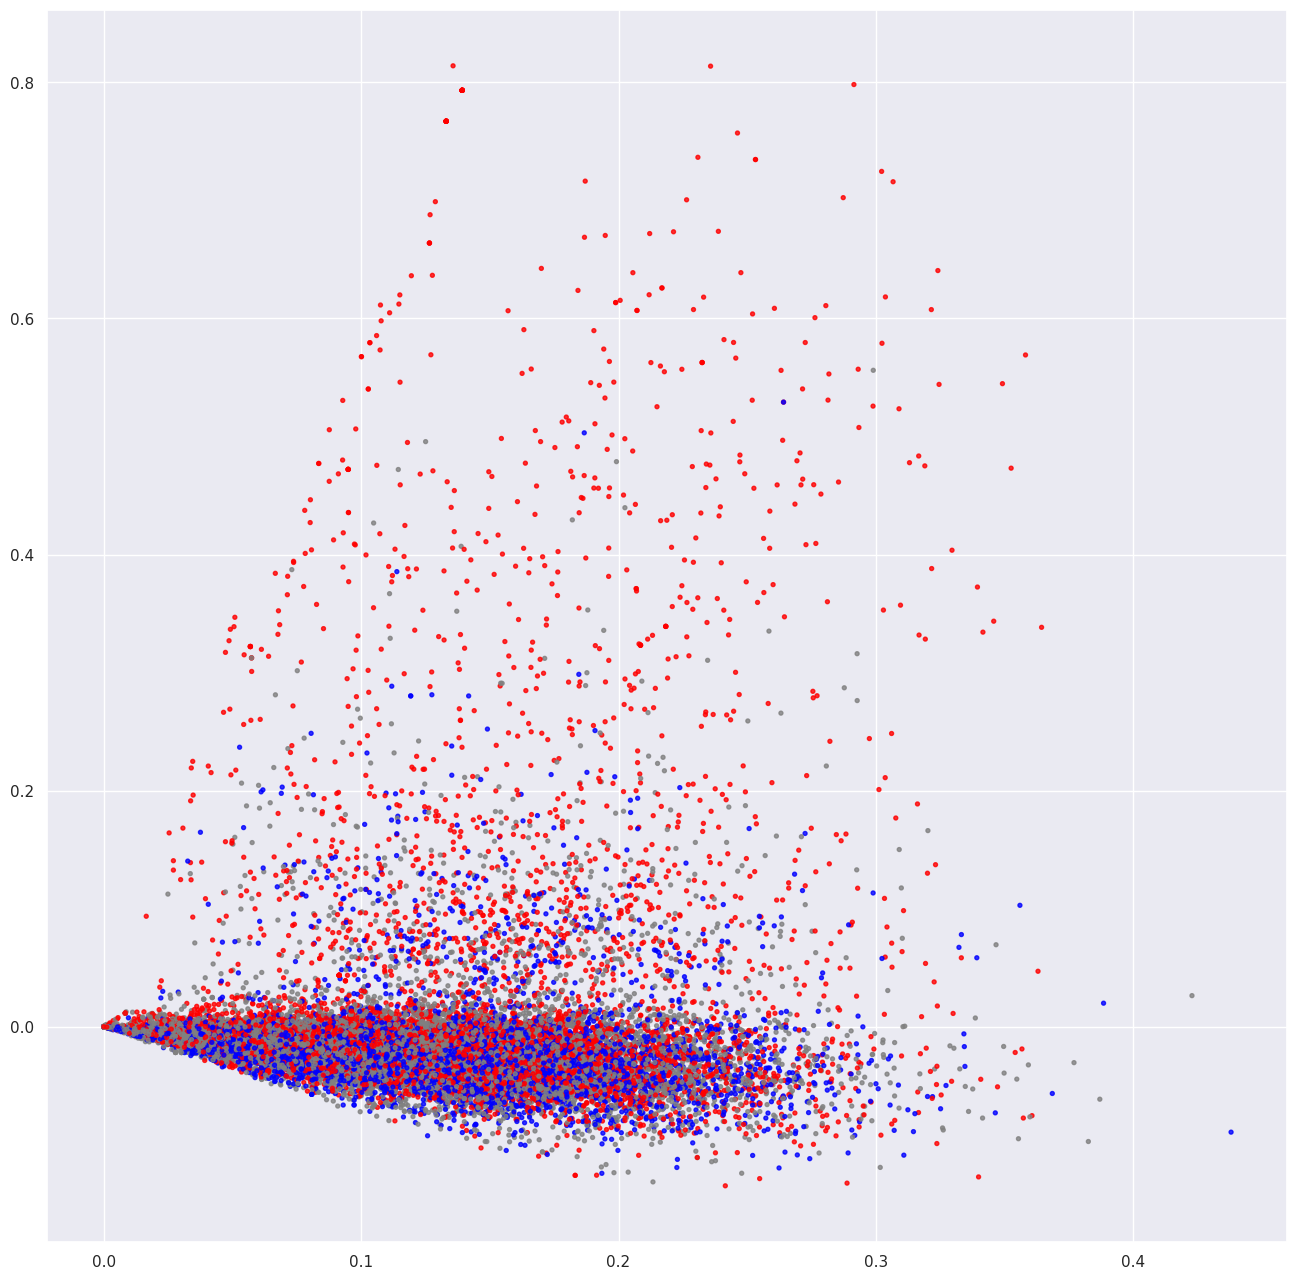

In [61]:
def tfidf(data):
    tfidf_vectorizer = TfidfVectorizer()

    train = tfidf_vectorizer.fit_transform(data)

    return train, tfidf_vectorizer

X_train_tfidf, tfidf_vectorizer = tfidf(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
fig = plt.figure(figsize=(16, 16))
plot_LSA(X_train_tfidf, y_train)
plt.show()

Разделение настроений текстов стало несколько четче.

In [62]:
clf_tfidf = LogisticRegression(C=30.0, class_weight='balanced', solver='newton-cg',
                         multi_class='multinomial', n_jobs=-1, random_state=40)
clf_tfidf.fit(X_train_tfidf, y_train)
y_predicted_tfidf = clf_tfidf.predict(X_test_tfidf)

accuracy_tfidf, precision_tfidf, recall_tfidf, f1_tfidf, r2_tfidf = get_metrics(y_test, y_predicted_tfidf)
print("accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f, r2 = %.3f"  % (accuracy_tfidf, precision_tfidf, recall_tfidf, f1_tfidf, r2_tfidf))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


accuracy = 0.664, precision = 0.664, recall = 0.664, f1 = 0.664, r2 = 0.244


Помогло на 0,01 значения точности.

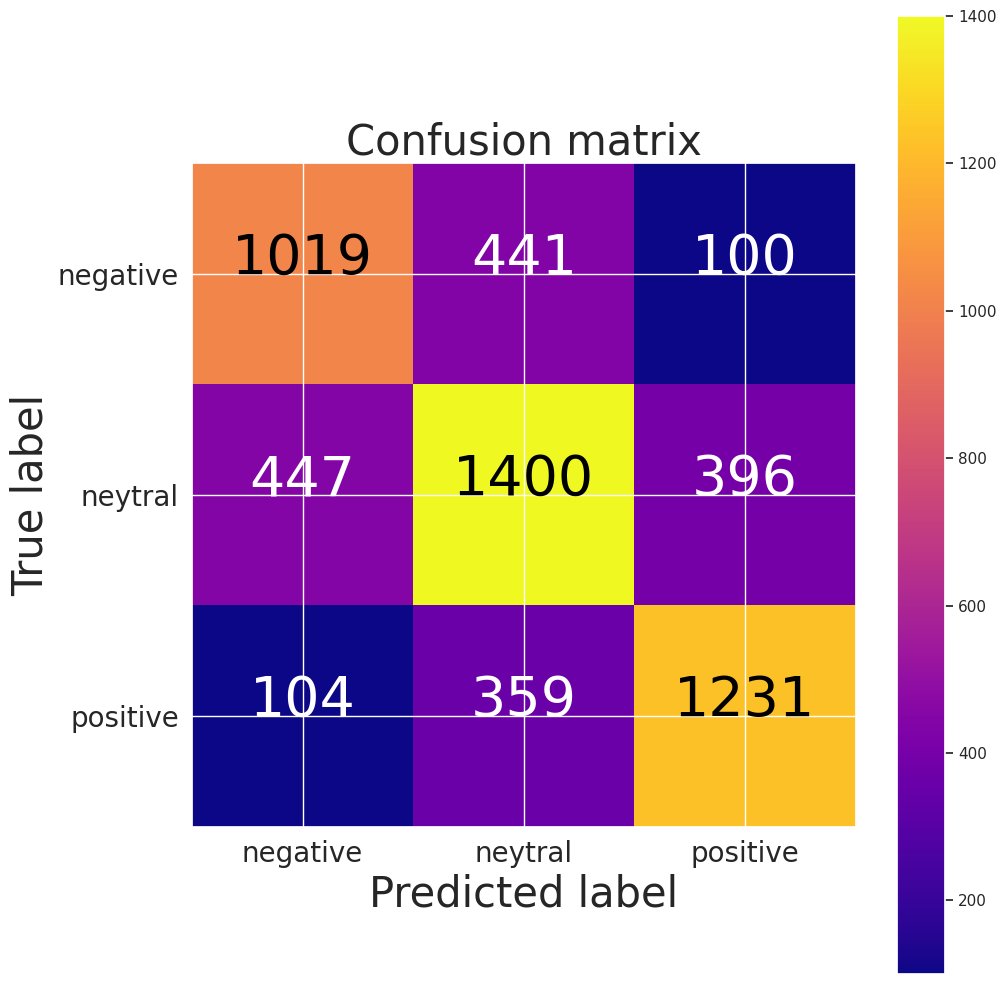

In [66]:
cm = confusion_matrix(y_test, y_predicted_tfidf)
fig = plt.figure(figsize=(10, 10))
plot = plot_confusion_matrix(cm, classes=["negative", "neytral", "positive"], normalize=False, title='Confusion matrix', cmap="plasma")
plt.show()

In [73]:
!pip install gensim
!python -m gensim.downloader --download word2vec-google-news-300

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.0 MB/s eta 0:00:00
2026-04-29 16:24:18,642 : __main__ : INFO : Creating /root/gensim-data
[==================================================] 100.0% 1662.8/1662.8MB downloaded
2026-04-29 16:25:59,539 : __main__ : INFO : word2vec-google-news-300 downloaded
2026-04-29 16:25:59,539 : __main__ : INFO : Data has been installed and data path is /root/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz


In [75]:
import gensim

# Loadin' Google's pre-trained Word2Vec model.
word2vec_path = "~/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz"
word2vec = gensim.models.KeyedVectors.load_word2vec_format(word2vec_path, binary=True)
def get_average_word2vec(tokens_list, vector, generate_missing=False, k=300):
    if len(tokens_list)<1:
        return np.zeros(k)
    if generate_missing:
        vectorized = [vector[word] if word in vector else np.random.rand(k) for word in tokens_list]
    else:
        vectorized = [vector[word] if word in vector else np.zeros(k) for word in tokens_list]
    length = len(vectorized)
    summed = np.sum(vectorized, axis=0)
    averaged = np.divide(summed, length)
    return averaged

def get_word2vec_embeddings(vectors, clean_questions, generate_missing=False):
    embeddings = clean_questions['tokens'].apply(lambda x: get_average_word2vec(x, vectors,
                                                                                generate_missing=generate_missing))
    return list(embeddings)


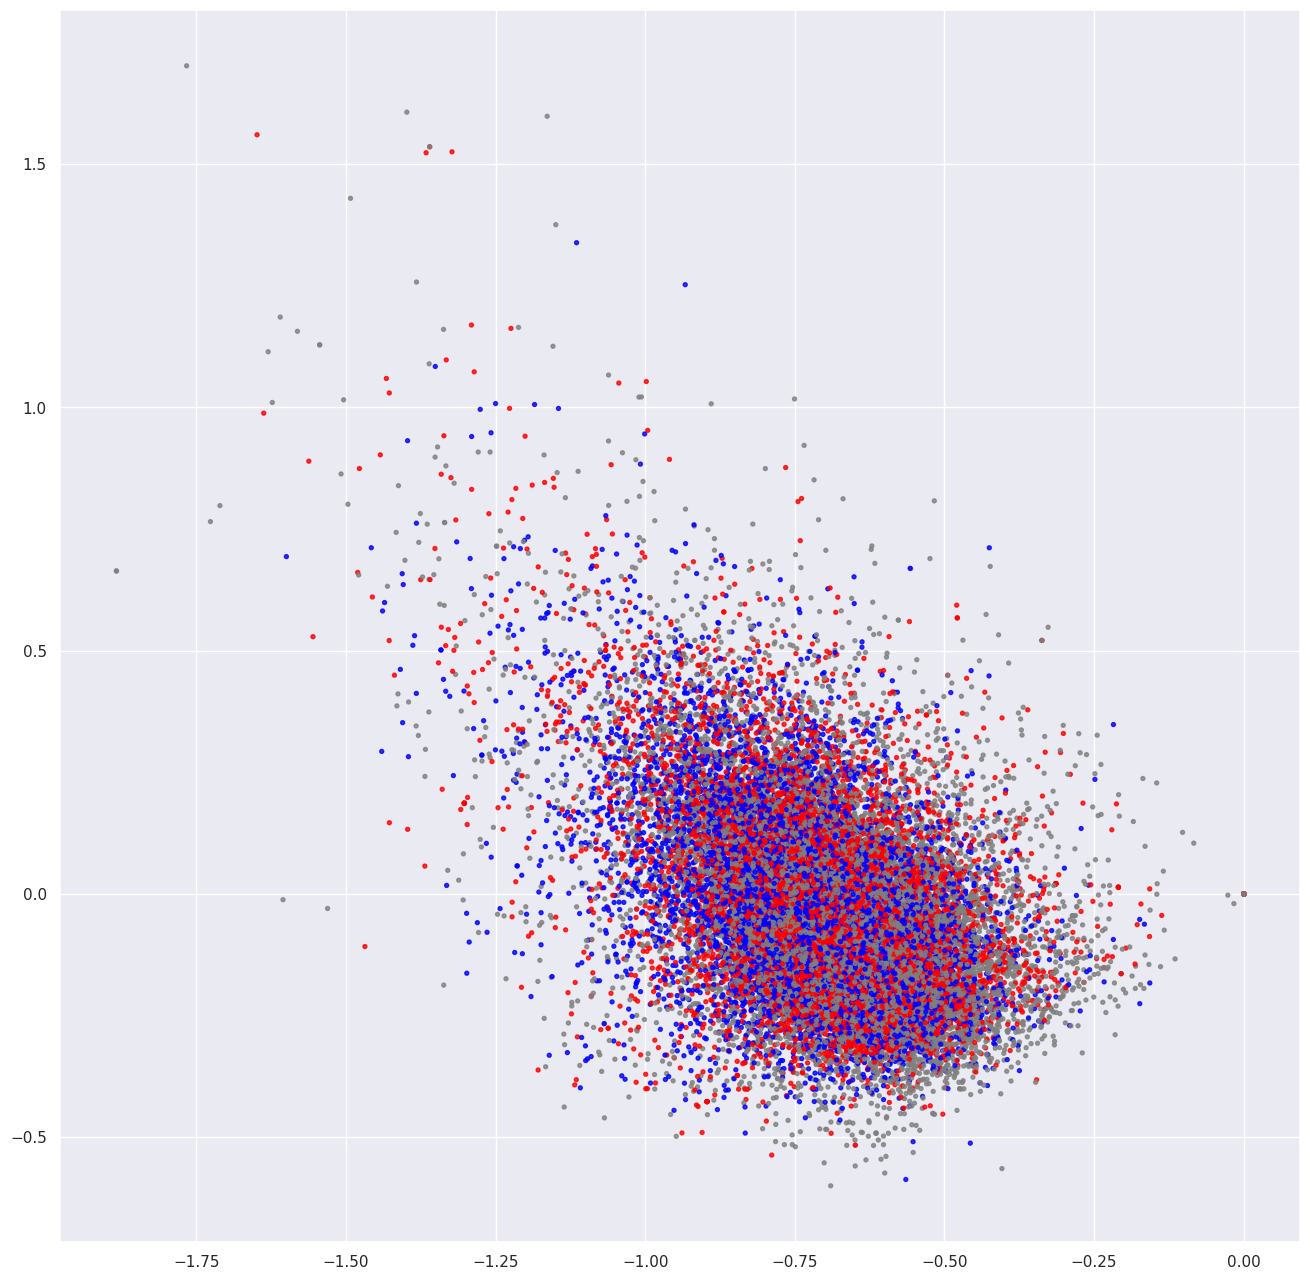

In [76]:
embeddings = get_word2vec_embeddings(word2vec, db)
X_train_word2vec, X_test_word2vec, y_train_word2vec, y_test_word2vec = train_test_split(embeddings, list_labels,
                                                                                        test_size=0.2, random_state=40)
fig = plt.figure(figsize=(16, 16))
plot_LSA(embeddings, list_labels)
plt.show()

Как было месиво - так и осталось.

In [77]:
clf_w2v = LogisticRegression(C=30.0, class_weight='balanced', solver='newton-cg',
                         multi_class='multinomial', random_state=40)
clf_w2v.fit(X_train_word2vec, y_train_word2vec)
y_predicted_word2vec = clf_w2v.predict(X_test_word2vec)

accuracy_word2vec, precision_word2vec, recall_word2vec, f1_word2vec, r2_word2vec = get_metrics(y_test_word2vec, y_predicted_word2vec)
print("accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f, r2 = %.3f" % (accuracy_word2vec, precision_word2vec, recall_word2vec, f1_word2vec, r2_word2vec))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


accuracy = 0.667, precision = 0.667, recall = 0.667, f1 = 0.667, r2 = 0.226


И точность снова почти не выросла.

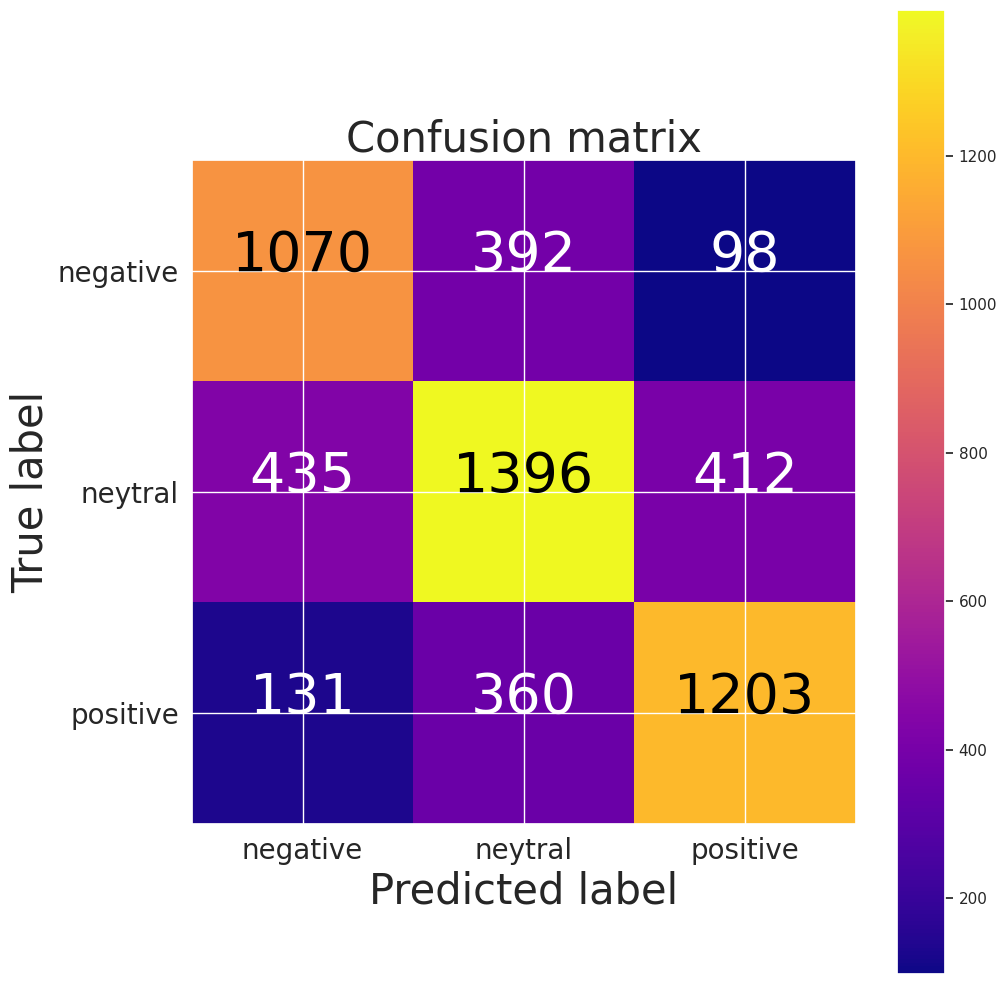

In [78]:
cm = confusion_matrix(y_test, y_predicted_word2vec)
fig = plt.figure(figsize=(10, 10))
plot = plot_confusion_matrix(cm, classes=["negative", "neytral", "positive"], normalize=False, title='Confusion matrix', cmap="plasma")
plt.show()

Воть.